In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import importlib, plotting_functions
importlib.reload(plotting_functions) 
from plotting_functions import plot_opinions

In [33]:
#import data 
data = pd.read_csv("anes_timeseries_2024_csv_20250808/anes_timeseries_2024_csv_20250808.csv", usecols = ['V241177'])

print(data['V241177'].unique())

[ 6  4  2 99  5  3  1  7 -9 -4]


In [35]:
data = pd.read_csv("anes_timeseries_2024_csv_20250808/anes_timeseries_2024_csv_20250808.csv")

data.head()

/var/folders/lk/p57c2c1x0kv0ptbl_lm3h0ww0000gn/T/ipykernel_97071/1371964961.py:1: DtypeWarning: Columns (8,10,11,16,18,19,20,22,23,24,26,27,28,30,31,36,38,39,1448,1449,1450,1451,1452,1455,1456,1457,1458,1459,1463,1464,1465) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("anes_timeseries_2024_csv_20250808/anes_timeseries_2024_csv_20250808.csv")


,version,V240001,V200001,V160001_orig,V240002a,V240002b,V240002c,V240003,V240101a,V240101b,...,V245009,V245010,V245011,V245012,V245013,V245014,V245015,V245016,V245017,V245018
0,ANES2024TimeSeries_20250808,140001,200015,401318,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
1,ANES2024TimeSeries_20250808,140002,200022,300261,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
2,ANES2024TimeSeries_20250808,140003,200039,400181,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
3,ANES2024TimeSeries_20250808,140004,200046,300171,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1
4,ANES2024TimeSeries_20250808,140005,200053,405145,2,2,2,1,,,...,-1,-1. Inapplicable,-1,-1,-1,-1,-1,-1,-1,-1


In [3]:
#filter data to remove votes corresponding to abstaining or errors
remove = [-9, -4, 99] # "Refused", "Error", "Havent thought much about this"
filtered = data[~data['V241177'].isin(remove)]
removed = data[data['V241177'].isin(remove)]

#convert to array
arr = filtered['V241177'].to_numpy()

print(data.shape)
print(filtered.shape)
print(removed.shape)

(5521, 1)
(4732, 1)
(789, 1)


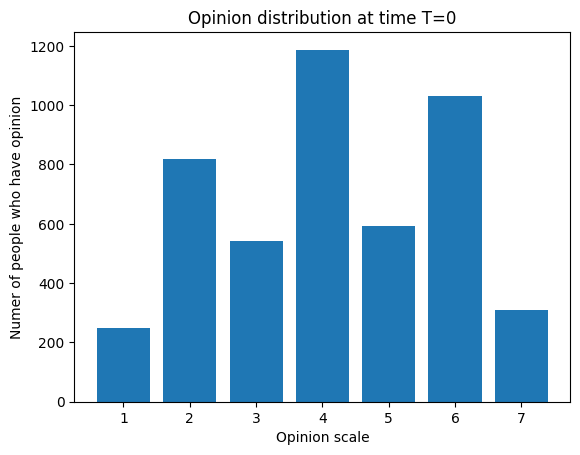

In [4]:
plt.hist(arr, bins=np.arange(arr.min() - 0.5, arr.max() + 1.5, 1), rwidth=0.8)
plt.xlabel('Opinion scale')
plt.ylabel('Numer of people who have opinion')
plt.title(f"Opinion distribution at time T=0")
plt.show()



## **Pre and Post Election Data**

In [30]:
#import data 
data = pd.read_csv("anes_timeseries_2020_csv_20220210/anes_timeseries_2020_csv_20220210.csv", usecols = ['V201151', 'V202143'])

print(data['V201151'].unique())
print(data['V202143'].unique())

[  0  65  70  15  85  50 100  60  75  40  80  30  72  -9  20  90  95  55
  84  35  97  10  58  96  86  62   5   1  25  51   9  61  87  49   2  48
  77  66  13   3  89  45   4  88  99  98  67  11   6  93  33  31  83  52
  26  12  63  73   7  36  69  -4  29 998]
[  0  15  85 100  50  70  60  80  30  75  -9  90  20  -6  40   7  95  86
  51  65  -7  72  82  10  98  55  88  25  35  -5  45  99  49   2  73   1
  16   5  69  87  62  58   8  89  96  23  61  77  37  68  63  33  41  97
   6  48  78   4  18  27  22  92   9  14  38  59  -4  42  12]


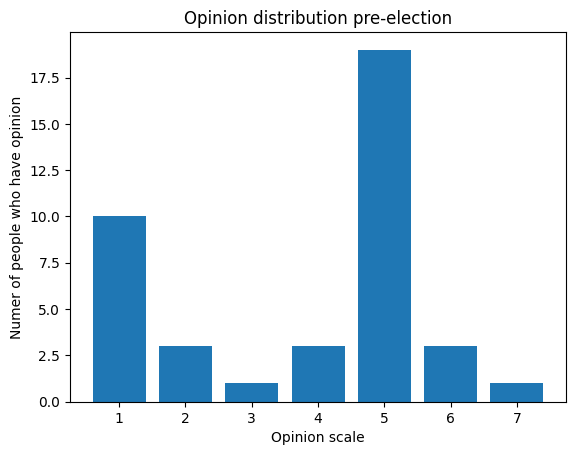

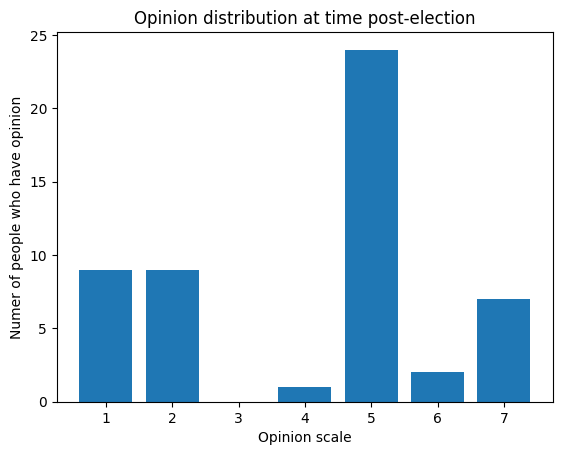

In [ ]:
remove = [998] # "Refused", "Error", "Havent thought much about this"
filtered = data[~(data['V201151'].isin(remove) | data['V202143'].isin(remove))]
removed = data[(data['V201151'].isin(remove) | data['V202143'].isin(remove))]


pre = filtered['V201151'].to_numpy()
post = filtered['V202143'].to_numpy()


plt.hist(pre, bins=np.arange(arr.min() - 0.5, arr.max() + 1.5, 1), rwidth=0.8)
plt.xlabel('Opinion scale')
plt.ylabel('Numer of people who have opinion')
plt.title(f"Opinion distribution pre-election")
plt.show()


plt.hist(post, bins=np.arange(arr.min() - 0.5, arr.max() + 1.5, 1), rwidth=0.8)
plt.xlabel('Opinion scale')
plt.ylabel('Numer of people who have opinion')
plt.title(f"Opinion distribution at time post-election")
plt.show()



In [5]:
def one_step(agent, agents):

    selected = np.where(np.abs(agents - agent) <= R)[0]
    update = np.average(agents[selected])
    
    return update

No advertisers


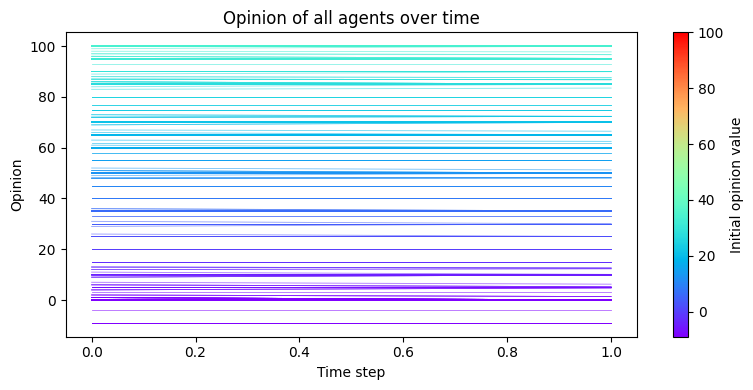

In [ ]:
agents = pre.copy()
# for a in agents:
def one_step_discrete(agent, agents):

    selected = np.where(np.abs(agents - agent) <= R)[0]
    update = np.average(agents[selected])
    
    return update

#inital state variables

n = len(pre) #number of agents
m = 0 # number of advertisers
R = 1.5 #opinion condfidance bound

rounds = 1

#initialize the agents
agents_initial = np.copy(agents) 

agents_history = np.zeros((rounds+1, len(agents)))
agents_history[0, :] = agents

#do t time steps (main loop)
for r in range(rounds):

    #make a temp list of agents
    agents_next = np.zeros(len(agents))

    #loop over all agents
    for i, a in enumerate(agents):
        agents_next[i] = one_step(a, agents)

    #update the agents list
    agents = np.copy(agents_next)
    agents_history[r+1, :] = agents


plot_opinions(agents_history, agents_initial, rounds = rounds, alpha=0.6)

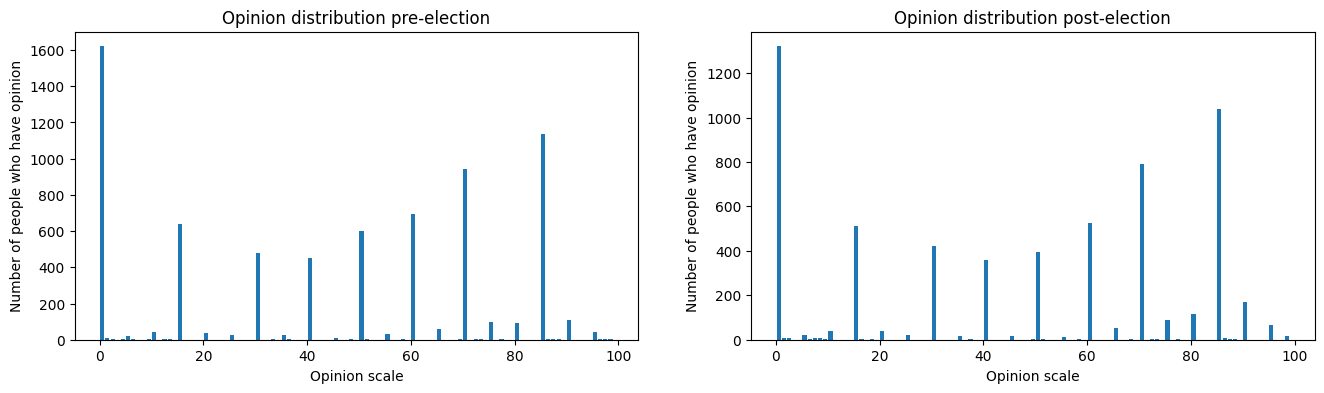

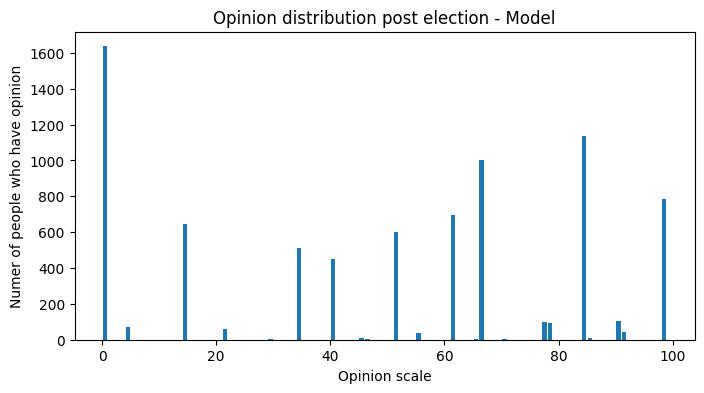

In [8]:
data = pd.read_csv("anes_timeseries_2020_csv_20220210/anes_timeseries_2020_csv_20220210.csv", usecols = ['V201151', 'V202143'])

remove = [-9, -4, 998]
filtered = data[~(data['V201151'].isin(remove) | data['V202143'].isin(remove))]
removed = data[(data['V201151'].isin(remove) | data['V202143'].isin(remove))]


pre = filtered['V201151'].to_numpy()
post = filtered['V202143'].to_numpy()

def one_step(agent, agents):

    selected = np.where(np.abs(agents - agent) <= R)[0]
    update = np.average(agents[selected])
    
    return update


def one_step_discrete(agent, agents):
    observed_agents = np.round(agents)

    selected = np.where(np.abs(observed_agents - agent) <= R)[0]

    update = np.average(observed_agents[selected])
    
    return update

# initial state variables
n = len(pre) 
m = 0 
R = 10

rounds = 1

# initialize the agents
agents = pre.copy()
agents_initial = np.copy(agents) 

agents_history = np.zeros((rounds+1, len(agents)))
agents_history[0, :] = agents

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Plot pre-election data on the first subplot
axes[0].hist(pre, bins=np.arange(0, 100, 1), rwidth=0.8)
axes[0].set_xlabel('Opinion scale')
axes[0].set_ylabel('Number of people who have opinion')
axes[0].set_title("Opinion distribution pre-election")

# Plot post-election data on the second subplot
axes[1].hist(post, bins=np.arange(0, 100, 1), rwidth=0.8)
axes[1].set_xlabel('Opinion scale')
axes[1].set_ylabel('Number of people who have opinion')
axes[1].set_title("Opinion distribution post-election")

plt.show()

for r in range(rounds):
    agents_next = np.zeros(len(agents))

    for i, a in enumerate(agents):
        agents_next[i] = one_step(a, agents)

    agents = np.copy(agents_next)
    agents_history[r+1, :] = agents

    observed_opinion = np.round(agents_history)

    plt.figure(figsize=(8,4))
    plt.hist((agents), bins=np.arange(0, 100, 1), rwidth=0.8)
    plt.xlabel('Opinion scale')
    plt.ylabel('Numer of people who have opinion')
    plt.title(f"Opinion distribution post election - Model")
    plt.show()


# plot_opinions(observed_opinion, agents_initial, rounds=rounds, alpha=0.6)